# Fit simultaneously 2 scans

created by Louise on the 18-05-2026


*12/03 :*
- 151636	0	
- 153852	45	
- 160306	90	
- 162802	0	
- 165051	0	
- 171415	0	
- 173723	0	

*16/03 :*

Sans la mousse dans la monture du polariseur :
- 102744	45	
- 110025	90	
- 113149	90	
- 120110	45	
- 122830	-45
- 135415	-90	

En inclinant le polairseur d'un angle phi :
- 143949	0  
- 151256	90


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
import data_manage_lib as dml
from importlib import reload
from scipy.optimize import least_squares

%matplotlib widget

In [2]:
dir_test_IAS = '/home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/'

### Plots settings
plot_path = dir_test_IAS + 'Plots/'
save_plots = False

In [77]:
reload(dml)
### Load data
data_path = dir_test_IAS + 'Data/'
scans = ['20260316_143949', '20260316_151256']

traces = ['S21', 'S12', 'S11', 'S22']

allthetaR = []
allmag = []
for scan in scans:
    freqs, mag, phi, header = dml.load_measurement_from_fits(data_path, scan)
    allthetaR.append(header['THETA_R'])
    allmag.append(mag)

allmag = np.array(allmag)
allthetaR = np.array(allthetaR)
print(f"Loaded data for {len(scans)} scans with angles: {allthetaR}")

### Check shape of magnitude data [(nstep, nS, points)]
print(allmag.shape) 
nscans, nstep, nS, nfreqs = allmag.shape
print(f"Number of scans: {nscans}, Number of steps: {nstep}, number of S-parameters: {nS}, number of frequency points: {nfreqs}")

### Identify index of first frequency sample above 127 GHz
fstart_ind = np.argwhere(freqs > 127)[0][0]
print(f"First frequency sample above 127 GHz is at index {fstart_ind}, corresponding to {freqs[fstart_ind]:.2f} GHz")


### Convert magnitude from dB to linear scale
allmag_lin = 10**(allmag/10)

### Average magnitude over frequencies above 127 GHz
mean_mag_lin = np.mean(allmag_lin[:, :, :, fstart_ind:], axis=-1)
print(f"Shape of mean magnitude after averaging over frequencies: {mean_mag_lin.shape}")

### Extract parameters from header
alpha_min = header['ALPH_MI']
alpha_max = header['ALPH_MA']
step = header['STEP']
nfreq = header['POINTS']

alpha = np.arange(alpha_min, alpha_max + step, step)
print(alpha.shape)

FITS file loaded: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Scan_20260316_143949.fits
FITS file loaded: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Scan_20260316_151256.fits
Loaded data for 2 scans with angles: [90  0]
(2, 39, 4, 242)
Number of scans: 2, Number of steps: 39, number of S-parameters: 4, number of frequency points: 242
First frequency sample above 127 GHz is at index 73, corresponding to 128.00 GHz
Shape of mean magnitude after averaging over frequencies: (2, 39, 4)
(39,)


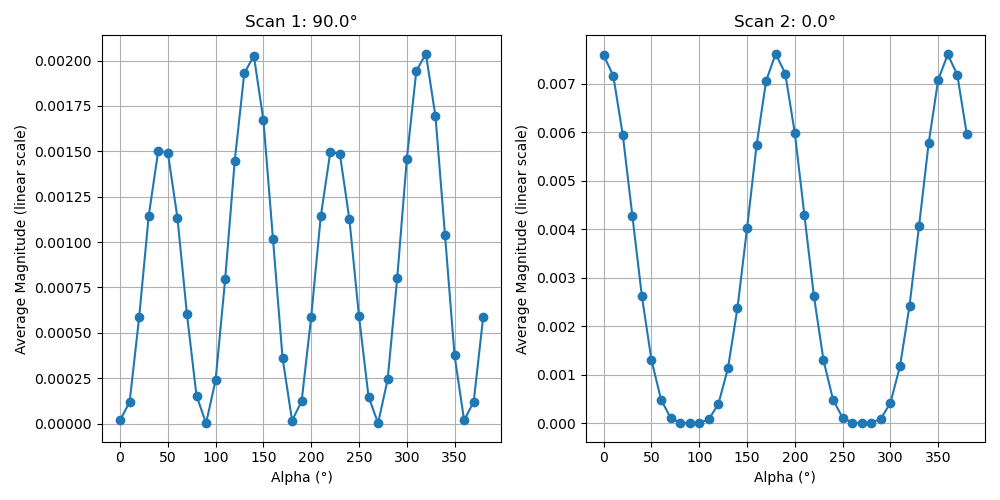

In [78]:
t = 0 # S21
ifreq = 100
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs = axs.flatten()
axs[0].plot(alpha, allmag_lin[0, :, t, ifreq], 'o-')
axs[0].set_xlabel('Alpha (°)')
axs[0].set_ylabel('Average Magnitude (linear scale)')
axs[0].set_title(f'Scan 1: {allthetaR[0]:.1f}°')
axs[0].grid()

axs[1].plot(alpha, allmag_lin[1, :, t, ifreq], 'o-')
axs[1].set_xlabel('Alpha (°)')
axs[1].set_ylabel('Average Magnitude (linear scale)')
axs[1].set_title(f'Scan 2: {allthetaR[1]:.1f}°')
axs[1].grid()

fig.tight_layout()

In [ ]:
# Define the trigonometric model
def mymodel(alpha, amplitude, theta_E, theta_R):
    return amplitude * np.cos(np.radians(theta_E - alpha))**2 * np.cos(np.radians(theta_R - alpha))**2

# Combined residuals for both scans
def combined_residuals(params, alpha, mag_scan1, mag_scan2, Delta):
    """
    Calculate combined residuals for simultaneous fit
    params: [theta_R1, amplitude, offset]
    delta_theta_R: known difference between scan 2 and scan 1
    """
    amplitude, theta_E, theta_R1 = params
    theta_R2 = theta_R1 + Delta
    
    pred_scan1 = mymodel(alpha, amplitude, theta_E, theta_R1)
    pred_scan2 = mymodel(alpha, amplitude, theta_E, theta_R2)
    
    residuals = np.concatenate([
        mag_scan1 - pred_scan1,
        mag_scan2 - pred_scan2
    ])
    return residuals

In [88]:
f = 122

# Known parameters
Delta = allthetaR[1] - allthetaR[0]  # Difference between scan 2 and scan 1
print(f"  Delta theta_R: {Delta:.2f}° (known)")

all_amplitude_fit = np.zeros(nfreqs)
all_theta_E_fit = np.zeros(nfreqs)
all_theta_R1_fit = np.zeros(nfreqs)

all_residuals_scan1 = np.zeros((nfreqs, len(alpha)))
all_residuals_scan2 = np.zeros((nfreqs, len(alpha)))

all_chi2red_scan1 = np.zeros(nfreqs)
all_chi2red_scan2 = np.zeros(nfreqs)

for f in range(fstart_ind, nfreqs):

    # Initial guess for parameters
    thetaE_init = 0  # Initial guess for theta_E
    theta_R1_init = allthetaR[0]
    amplitude_init = (np.max(allmag_lin[0, :, t, f]) - np.min(allmag_lin[0, :, t, f])) / 2

    # Combine data for fitting
    mag_combined = np.concatenate([allmag_lin[0, :, t, f], allmag_lin[1, :, t, f]])
    alpha_combined = np.concatenate([alpha, alpha])


    params_init = [amplitude_init, thetaE_init, theta_R1_init]
    result = least_squares(
        combined_residuals, 
        params_init,
        args=(alpha, allmag_lin[0, :, t, f], allmag_lin[1, :, t, f], Delta)
    )

    amplitude_fit, thetaE_fit, theta_R1_fit= result.x
    theta_R2_fit = theta_R1_fit + Delta

    all_amplitude_fit[f] = amplitude_fit
    all_theta_E_fit[f] = thetaE_fit
    all_theta_R1_fit[f] = theta_R1_fit

    # Fit curves
    fit_curve1 = mymodel(alpha, amplitude_fit, thetaE_fit, theta_R1_fit)
    fit_curve2 = mymodel(alpha, amplitude_fit, thetaE_fit, theta_R2_fit)

    # Residuals
    all_residuals_scan1[f, :] = allmag_lin[0, :, t, f] - fit_curve1
    all_residuals_scan2[f, :] = allmag_lin[1, :, t, f] - fit_curve2

    std_res_scan1 = np.std(all_residuals_scan1[f, :])
    std_res_scan2 = np.std(all_residuals_scan2[f, :])

    # chi2
    chi2_scan1 = dml.get_chi2(allmag_lin[0, :, t, f], fit_curve1, std_res_scan1)
    chi2_scan2 = dml.get_chi2(allmag_lin[1, :, t, f], fit_curve2, std_res_scan2)
   
    # chi2 réduit to check goodness of fit
    all_chi2red_scan1[f] = chi2_scan1 / (len(alpha) - len(result.x))
    all_chi2red_scan2[f] = chi2_scan2 / (len(alpha) - len(result.x))

    print(f"\n Fit results frequency {f}:")
    print(f"  Amplitude: {amplitude_fit:.4f}")
    print(f"  theta_E: {thetaE_fit:.2f}°")
    print(f"  theta_R1 (scan 1): {theta_R1_fit:.2f}°")
    print(f"  theta_R2 (scan 2): {theta_R2_fit:.2f}°")
    print(f"  Residual norm: {result.cost:.10f}")
    print(f"  Standard deviation of residuals scan 1: {std_res_scan1:.6f}")
    print(f"  Standard deviation of residuals scan 2: {std_res_scan2:.6f}")
    print(f"  Chi2 scan 1: {chi2_scan1:.6f}, Chi2 reduced scan 1: {all_chi2red_scan1[f]:.6f}")
    print(f"  Chi2 scan 2: {chi2_scan2:.6f}, Chi2 reduced scan 2: {all_chi2red_scan2[f]:.6f}")

  Delta theta_R: -90.00° (known)

 Fit results frequency 73:
  Amplitude: 0.0066
  theta_E: -1.08°
  theta_R1 (scan 1): 92.05°
  theta_R2 (scan 2): 2.05°
  Residual norm: 0.0000001979
  Standard deviation of residuals scan 1: 0.000042
  Standard deviation of residuals scan 2: 0.000086
  Chi2 scan 1: 39.133374, Chi2 reduced scan 1: 1.087038
  Chi2 scan 2: 44.430054, Chi2 reduced scan 2: 1.234168

 Fit results frequency 74:
  Amplitude: 0.0065
  theta_E: -1.02°
  theta_R1 (scan 1): 92.04°
  theta_R2 (scan 2): 2.04°
  Residual norm: 0.0000001097
  Standard deviation of residuals scan 1: 0.000035
  Standard deviation of residuals scan 2: 0.000060
  Chi2 scan 1: 44.999957, Chi2 reduced scan 1: 1.249999
  Chi2 scan 2: 46.708038, Chi2 reduced scan 2: 1.297446

 Fit results frequency 75:
  Amplitude: 0.0067
  theta_E: -1.09°
  theta_R1 (scan 1): 92.02°
  theta_R2 (scan 2): 2.02°
  Residual norm: 0.0000001154
  Standard deviation of residuals scan 1: 0.000035
  Standard deviation of residuals s

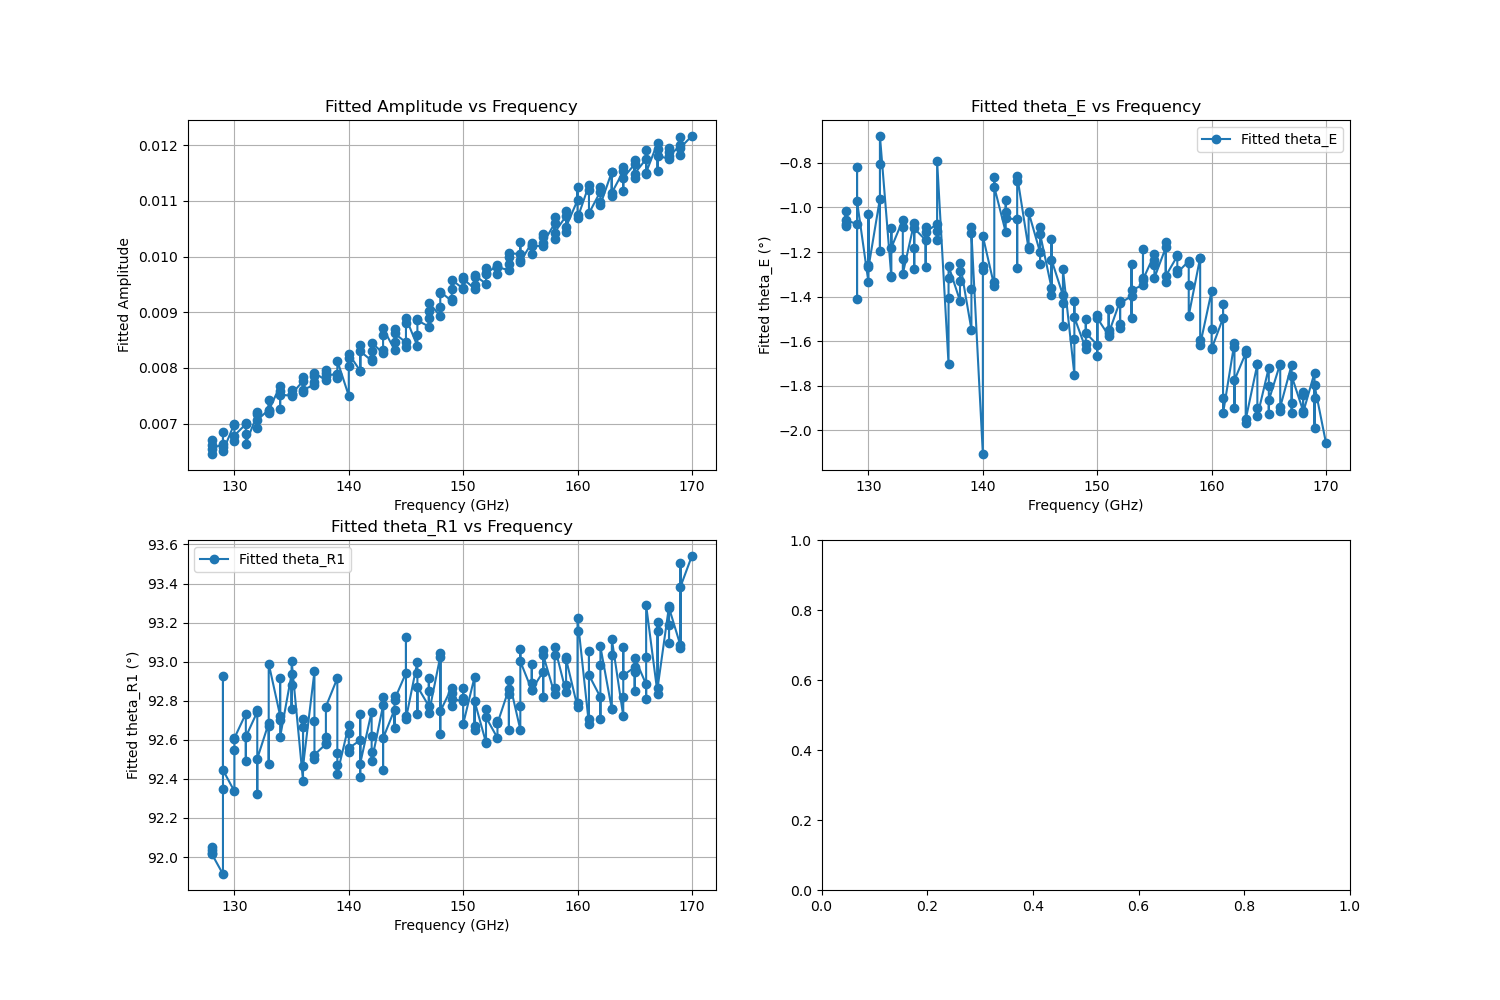

In [92]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

axs[0].plot(freqs[fstart_ind:], all_amplitude_fit[fstart_ind:], 'o-', label='Fitted Amplitude')
axs[0].set_xlabel('Frequency (GHz)')
axs[0].set_ylabel('Fitted Amplitude')
axs[0].set_title('Fitted Amplitude vs Frequency')
axs[0].grid()

axs[1].plot(freqs[fstart_ind:], all_theta_E_fit[fstart_ind:], 'o-', label='Fitted theta_E')
axs[1].set_xlabel('Frequency (GHz)')
axs[1].set_ylabel('Fitted theta_E (°)')
axs[1].set_title('Fitted theta_E vs Frequency')
axs[1].grid()
axs[1].legend()

axs[2].plot(freqs[fstart_ind:], all_theta_R1_fit[fstart_ind:], 'o-', label='Fitted theta_R1')
axs[2].set_xlabel('Frequency (GHz)')
axs[2].set_ylabel('Fitted theta_R1 (°)')
axs[2].set_title('Fitted theta_R1 vs Frequency')
axs[2].grid()
axs[2].legend()


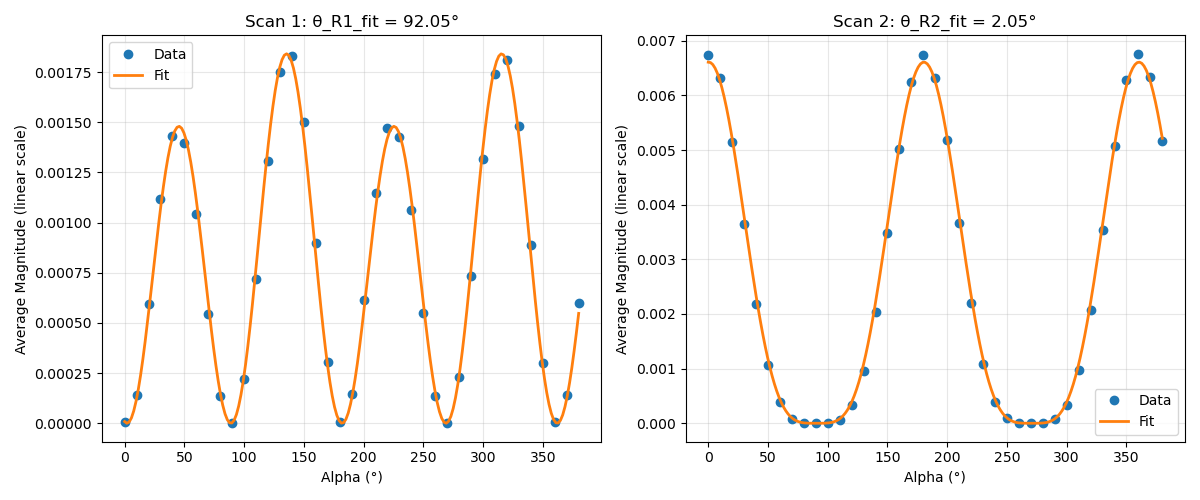

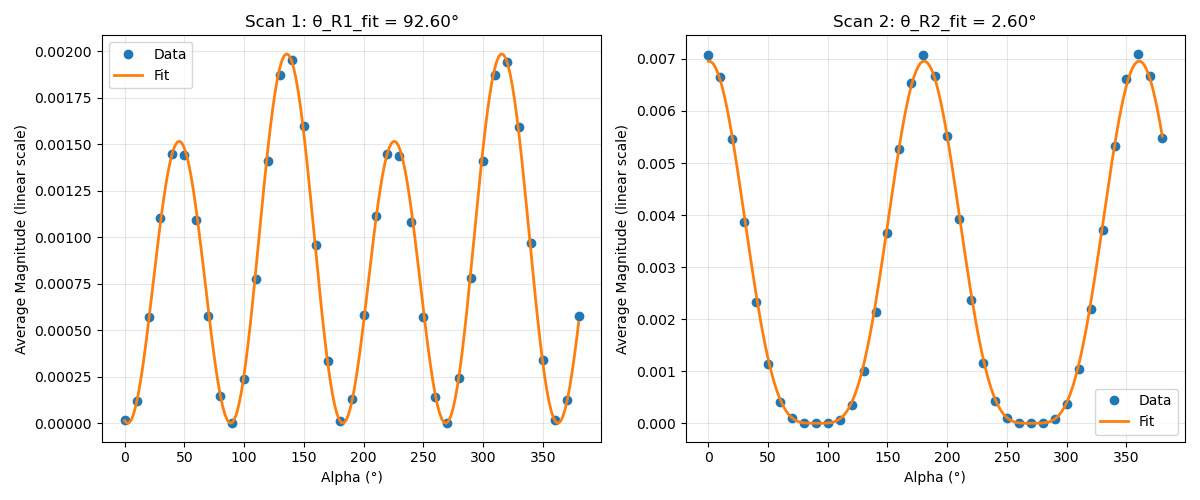

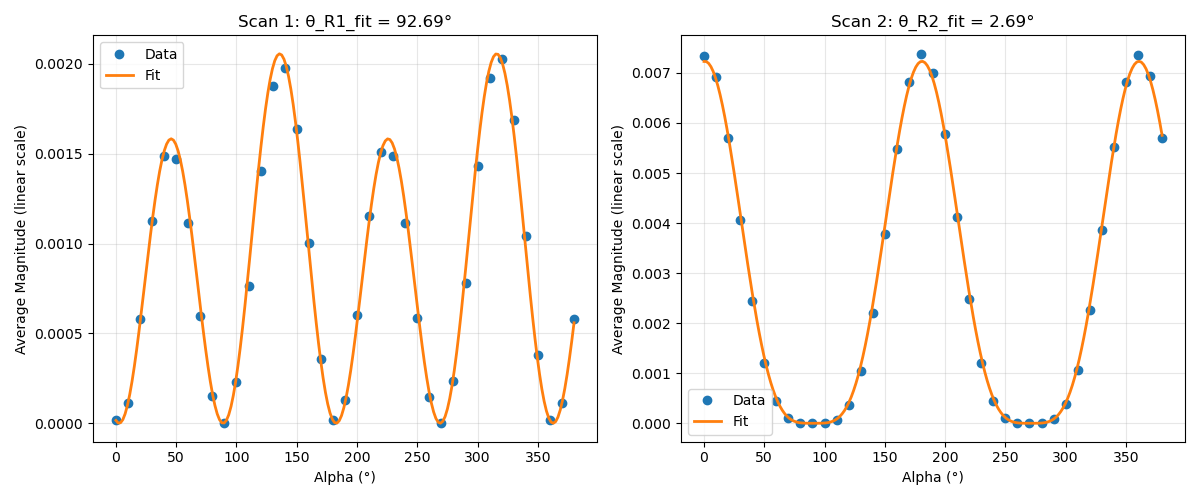

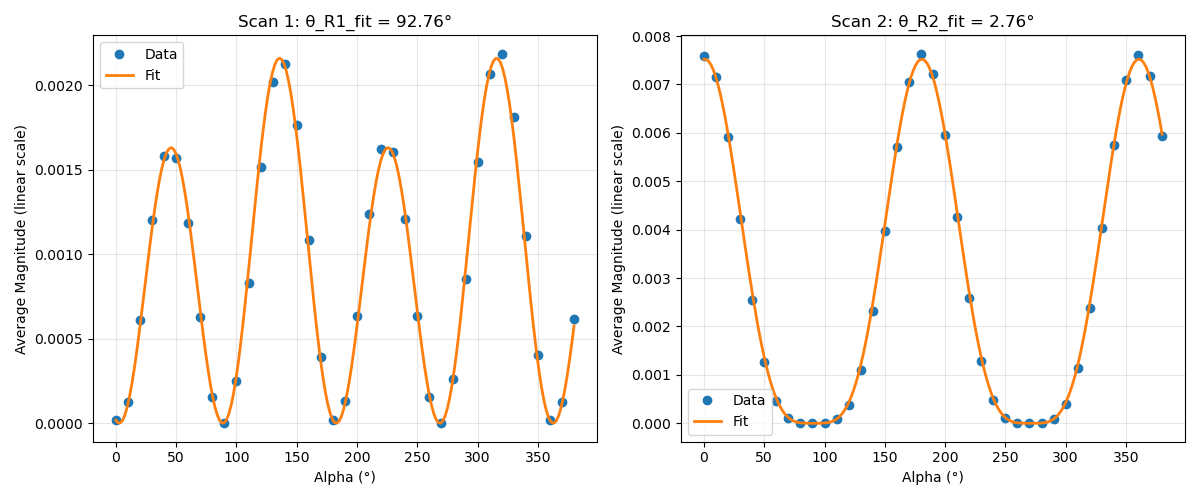

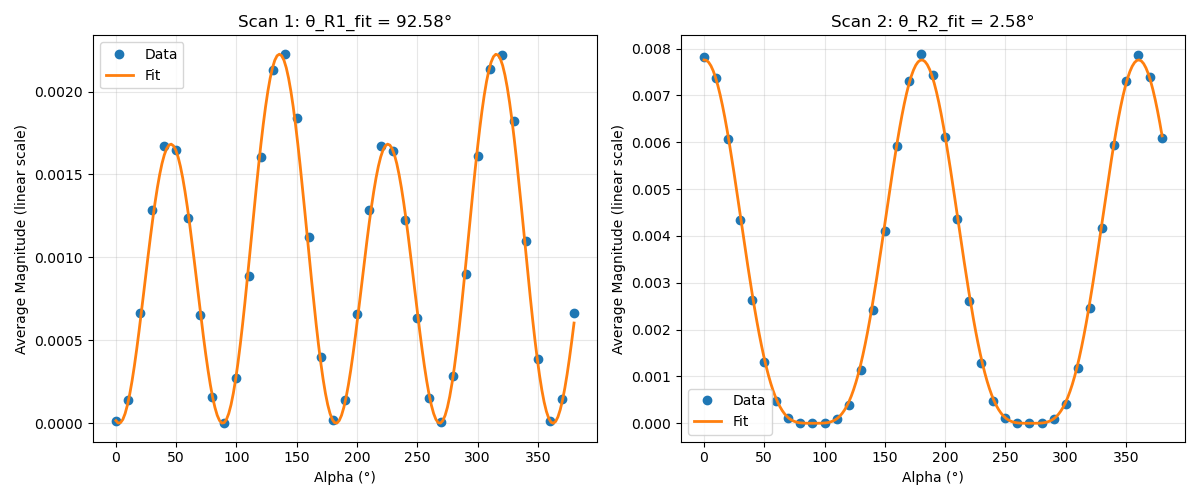

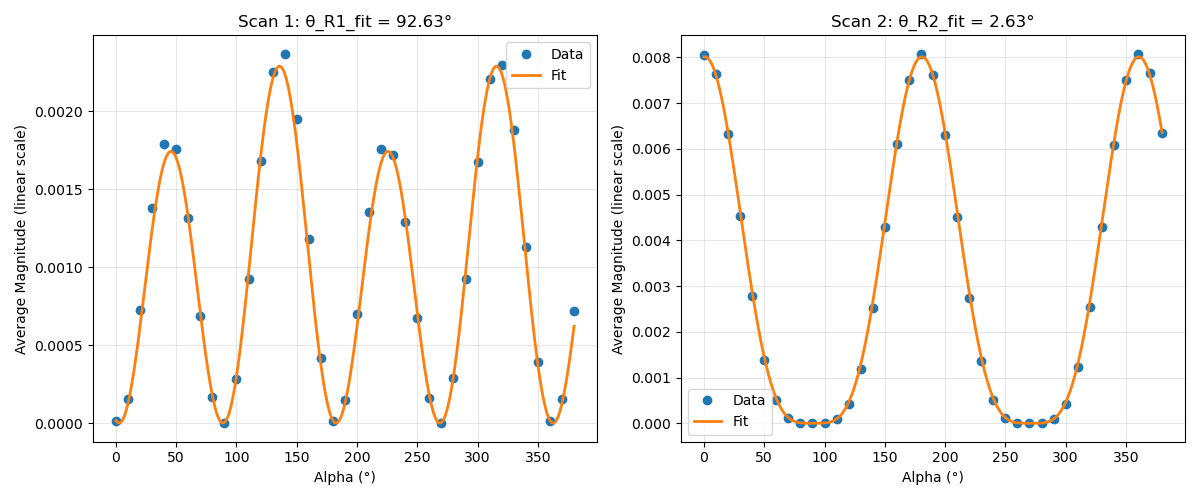

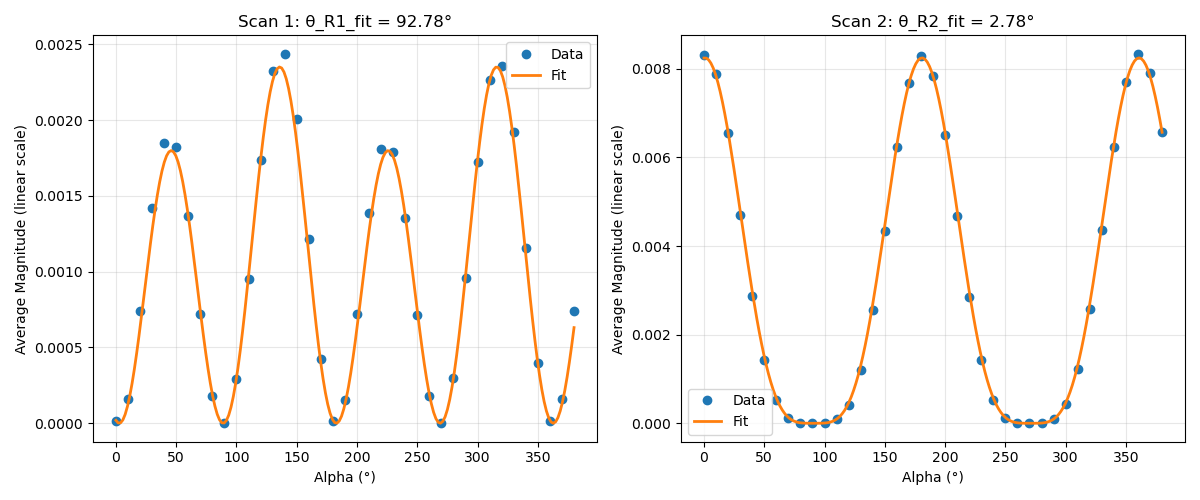

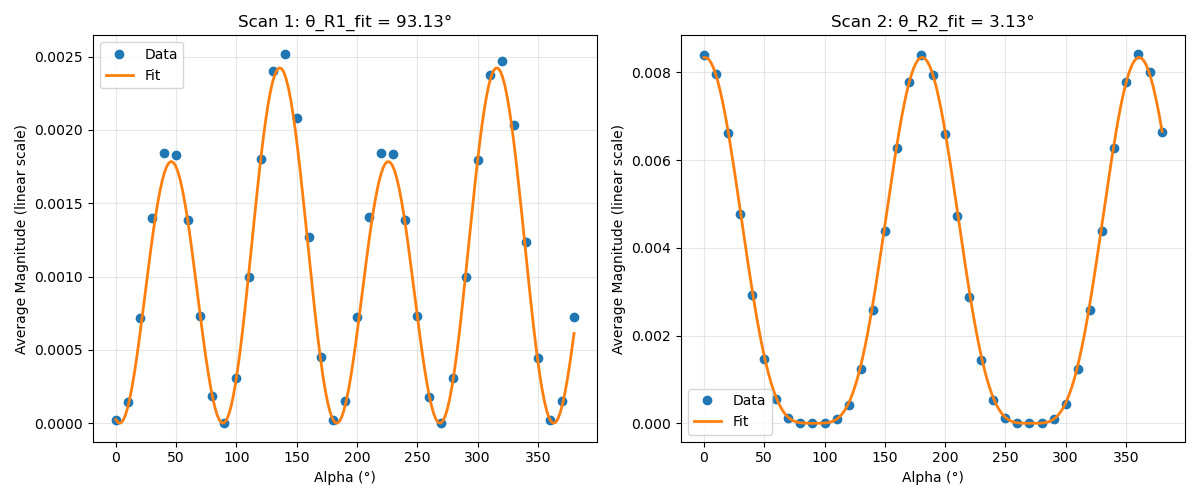

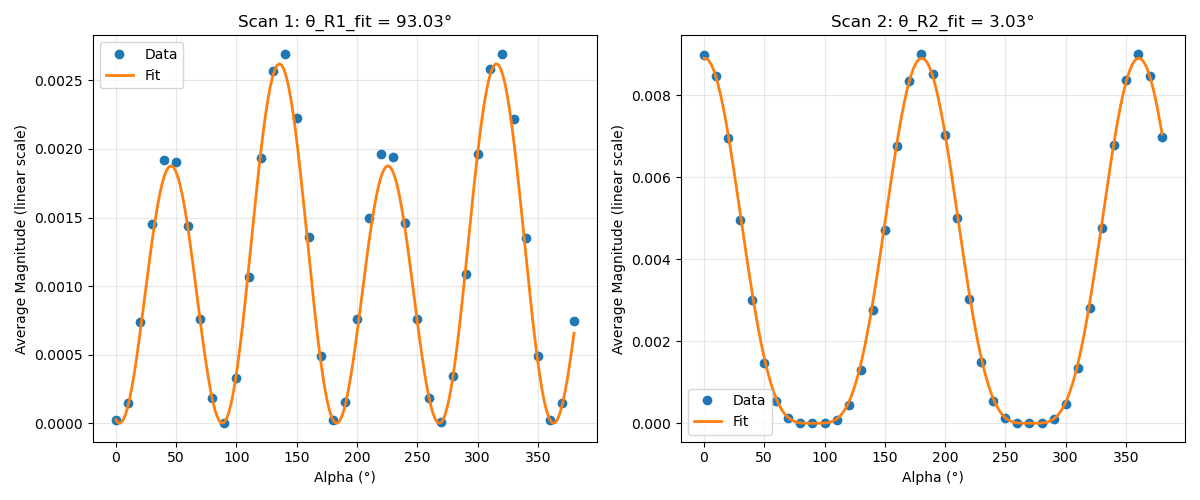

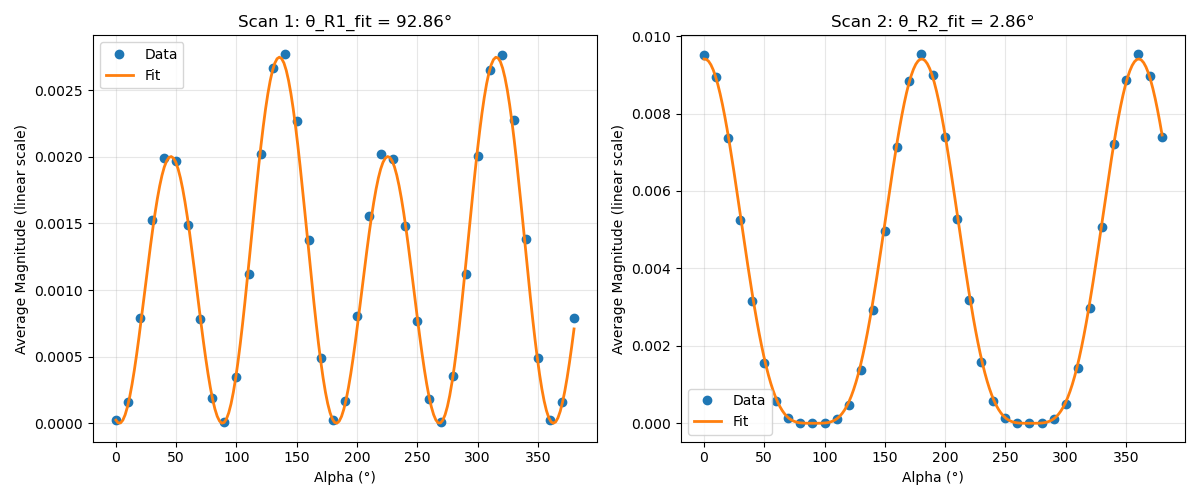

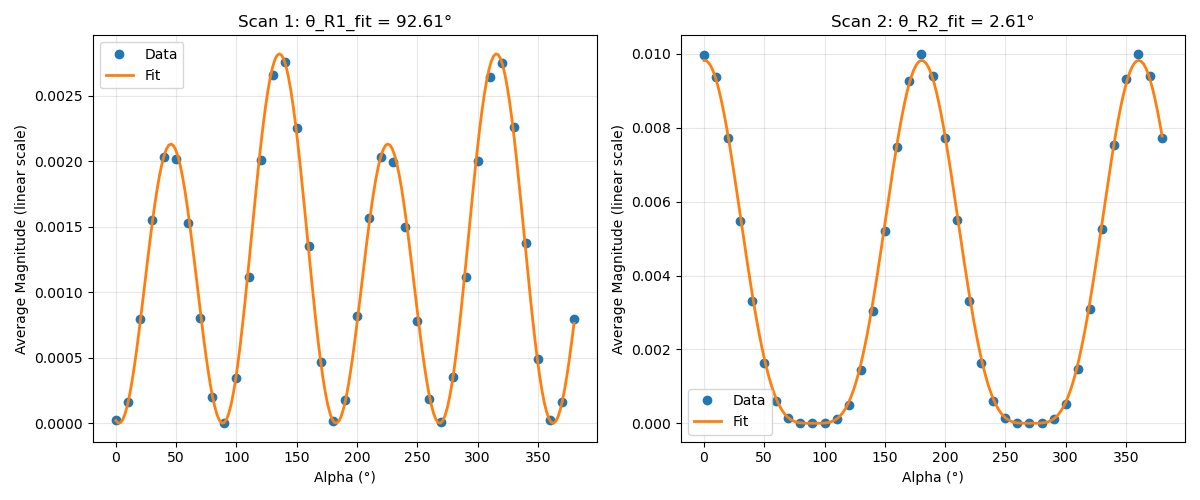

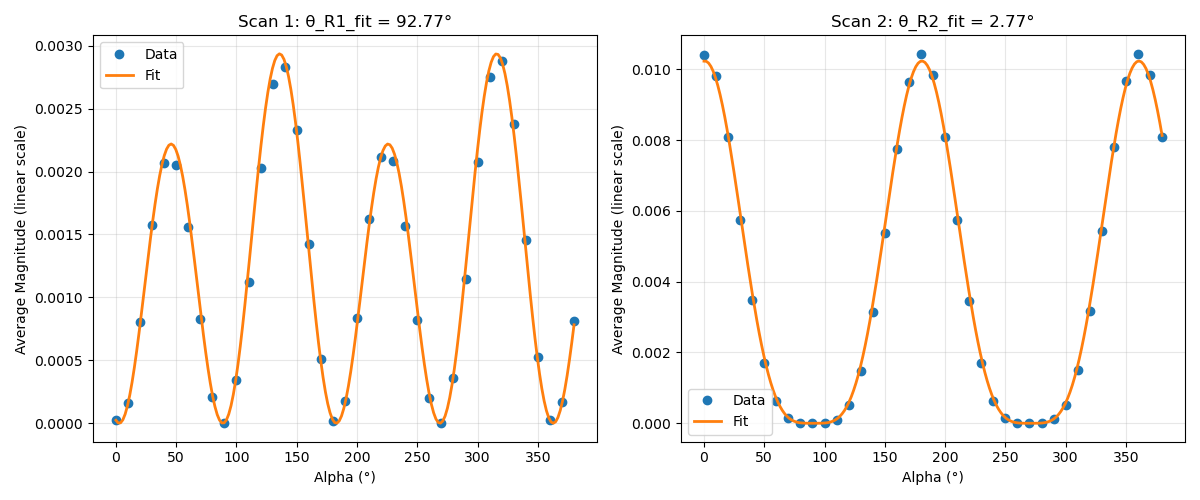

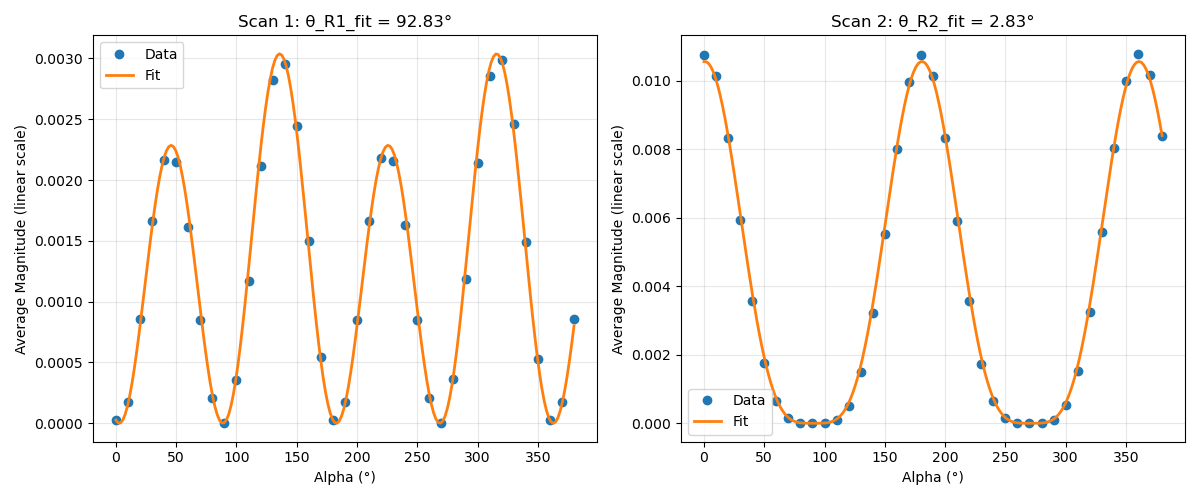

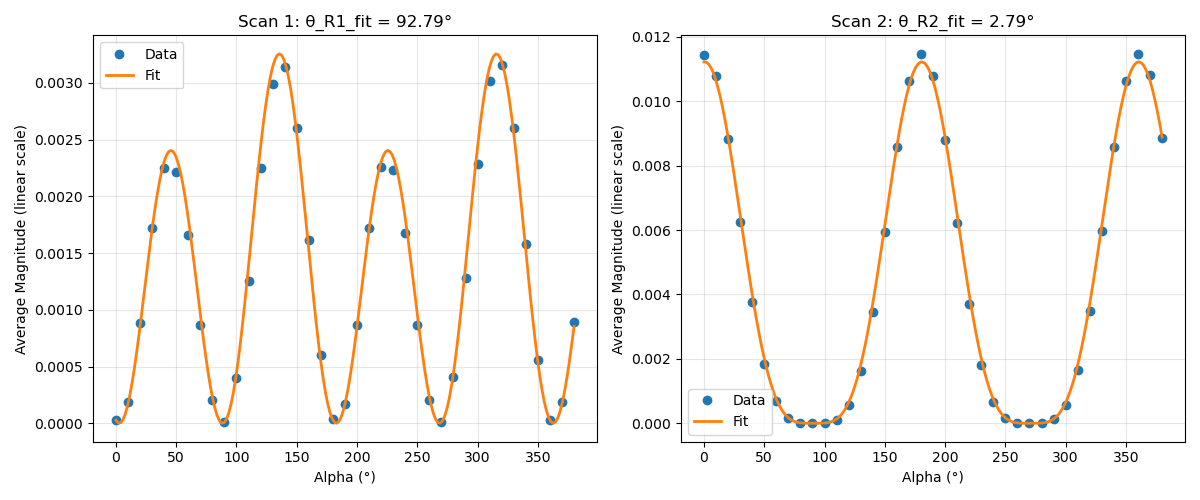

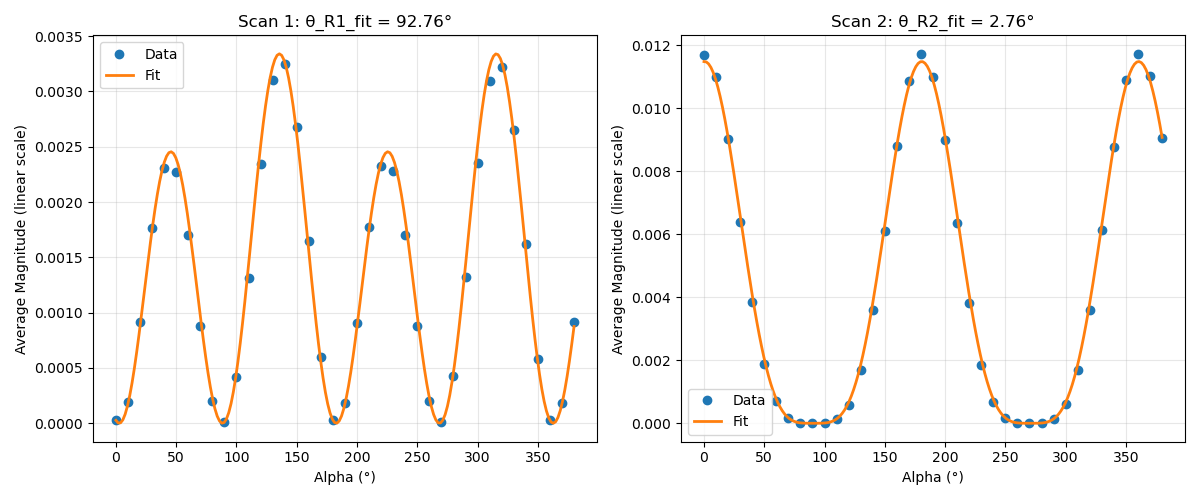

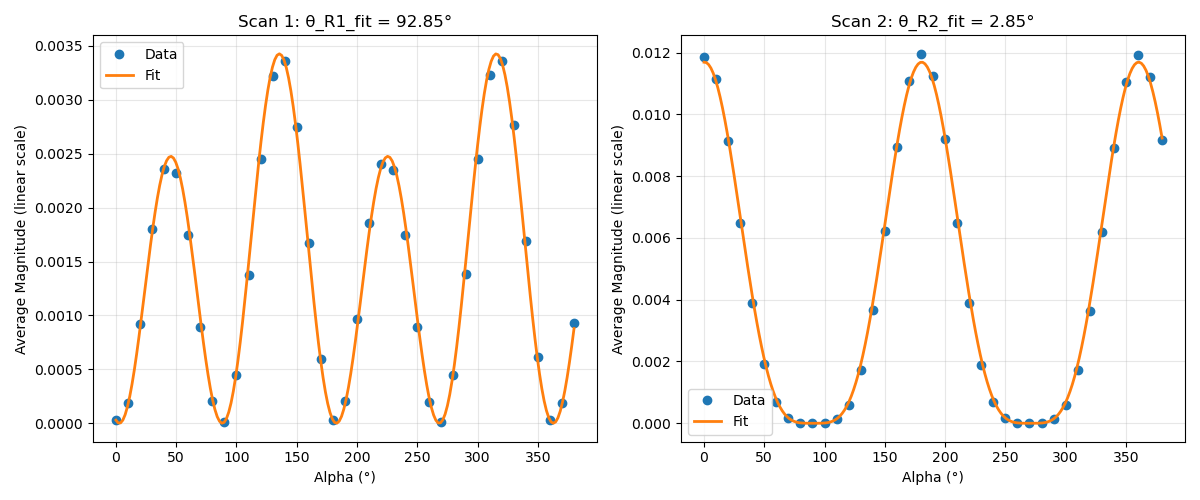

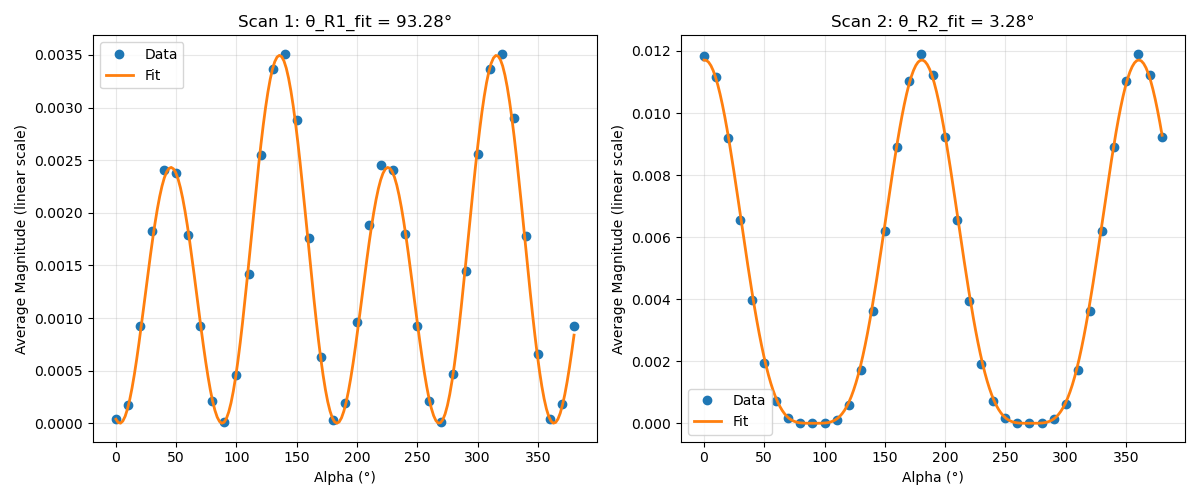

In [83]:
### Visualization of the fit

for f in range(fstart_ind, nfreqs, 10):  # Plot every 10th frequency to avoid overcrowding
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Generate smooth curves for plotting
    alpha_smooth = np.linspace(alpha.min(), alpha.max(), 200)
    fit_curve1 = mymodel(alpha_smooth, all_amplitude_fit[f], all_theta_E_fit[f], all_theta_R1_fit[f])
    fit_curve2 = mymodel(alpha_smooth, all_amplitude_fit[f], all_theta_E_fit[f], all_theta_R1_fit[f] + Delta)

    # Plot scan 1
    axs[0].plot(alpha, allmag_lin[0, :, t, f], 'o', label='Data', markersize=6)
    axs[0].plot(alpha_smooth, fit_curve1, '-', linewidth=2, label='Fit')
    axs[0].set_xlabel('Alpha (°)')
    axs[0].set_ylabel('Average Magnitude (linear scale)')
    axs[0].set_title(f'Scan 1: θ_R1_fit = {all_theta_R1_fit[f]:.2f}°')
    axs[0].grid(alpha=0.3)
    axs[0].legend()

    # Plot scan 2
    axs[1].plot(alpha, allmag_lin[1, :, t, f], 'o', label='Data', markersize=6)
    axs[1].plot(alpha_smooth, fit_curve2, '-', linewidth=2, label='Fit')
    axs[1].set_xlabel('Alpha (°)')
    axs[1].set_ylabel('Average Magnitude (linear scale)')
    axs[1].set_title(f'Scan 2: θ_R2_fit = {all_theta_R1_fit[f]+Delta:.2f}°')
    axs[1].grid(alpha=0.3)
    axs[1].legend()

    fig.tight_layout()
    plt.show()


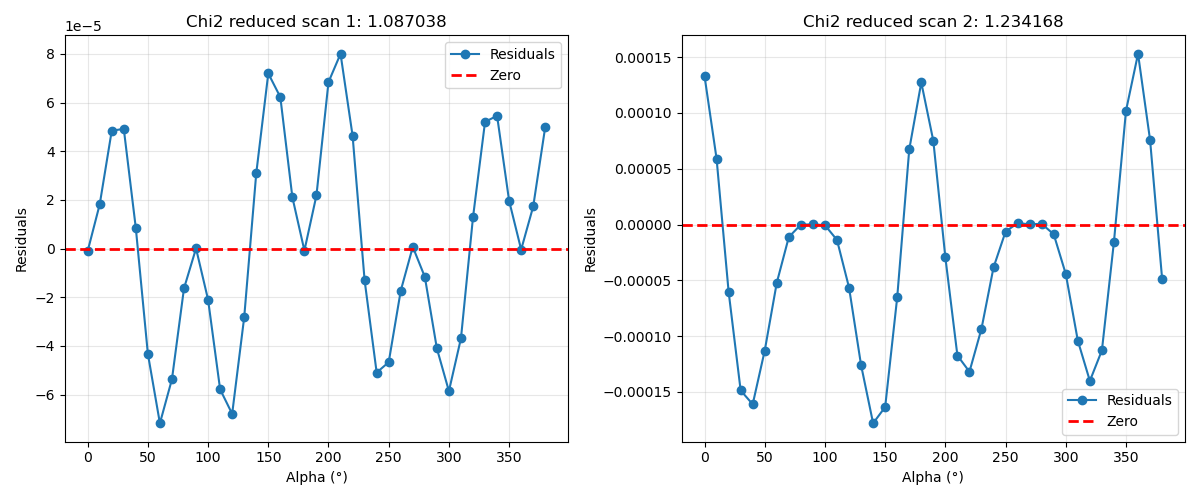

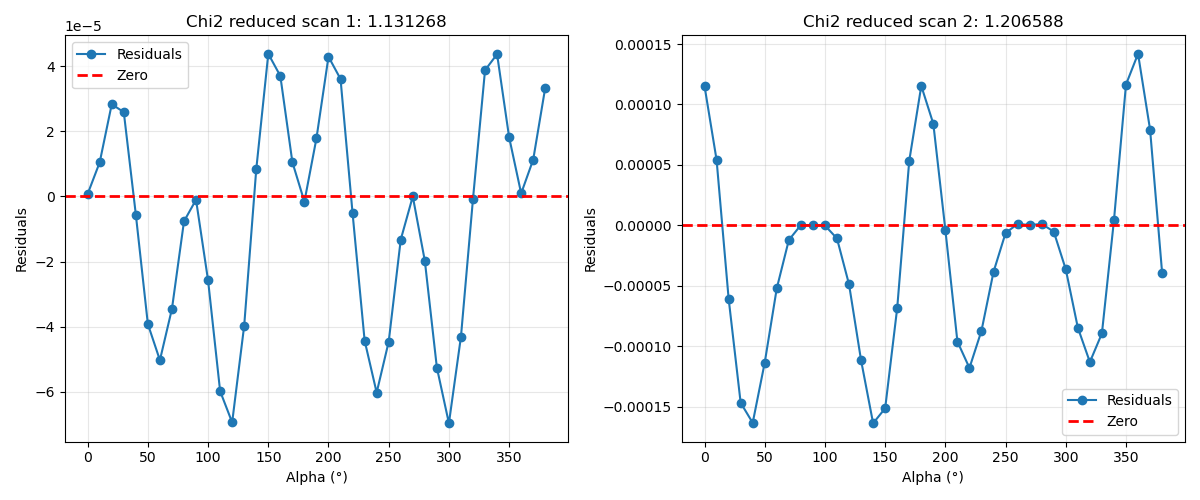

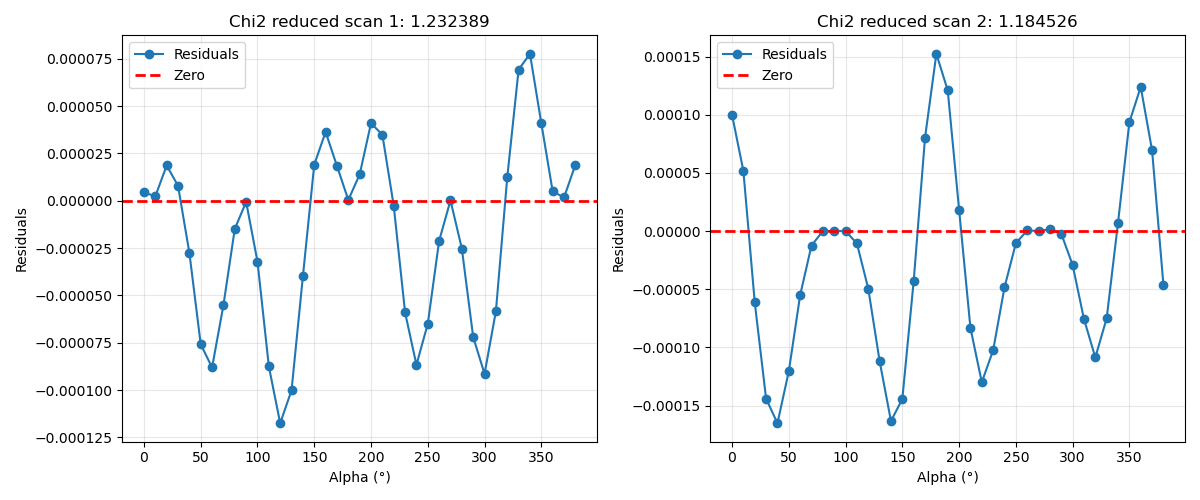

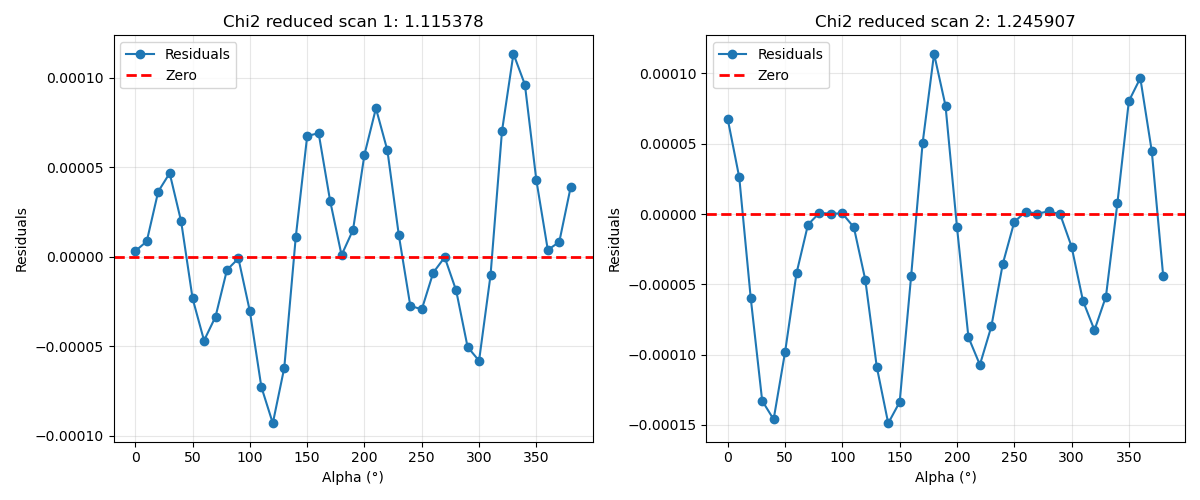

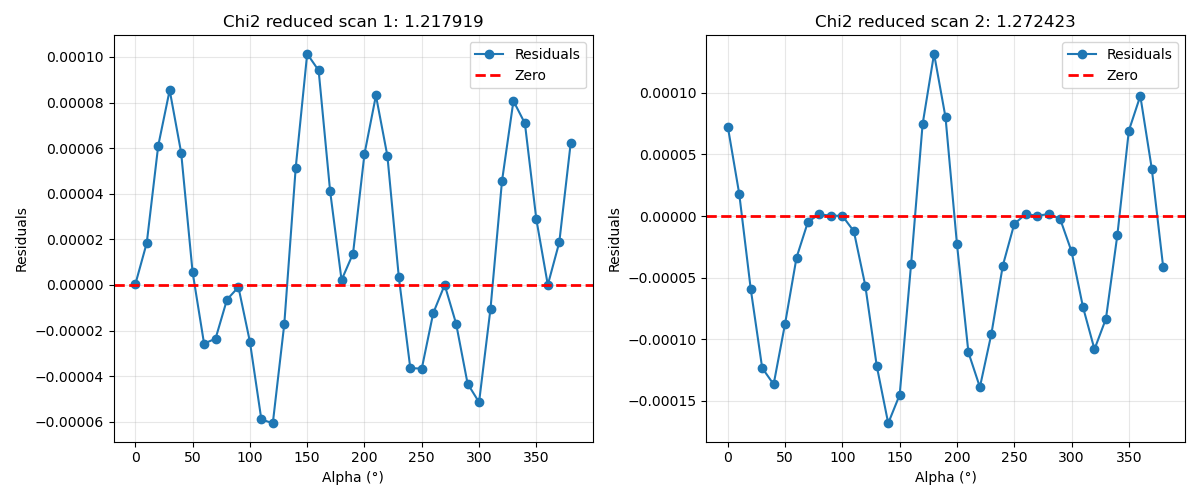

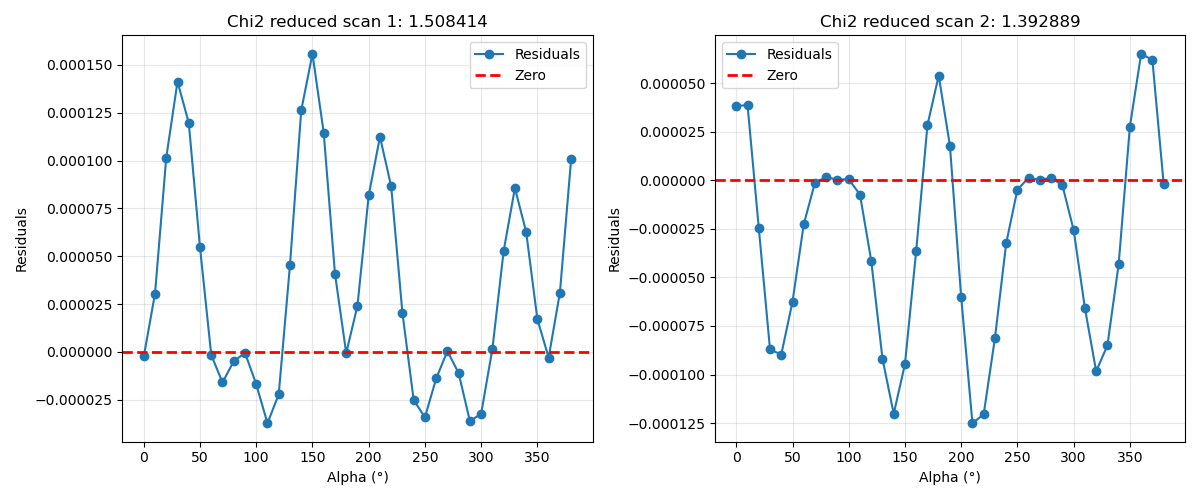

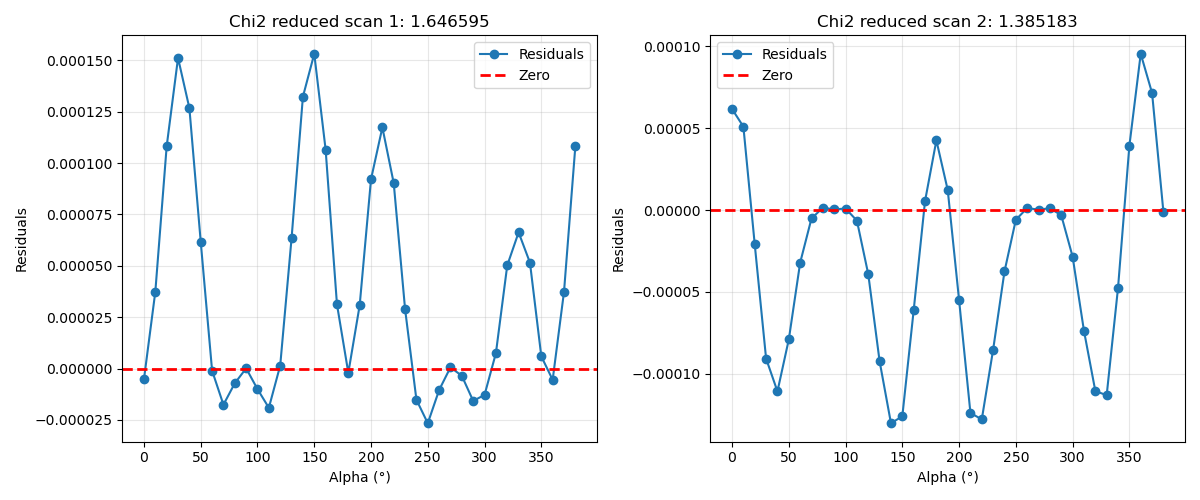

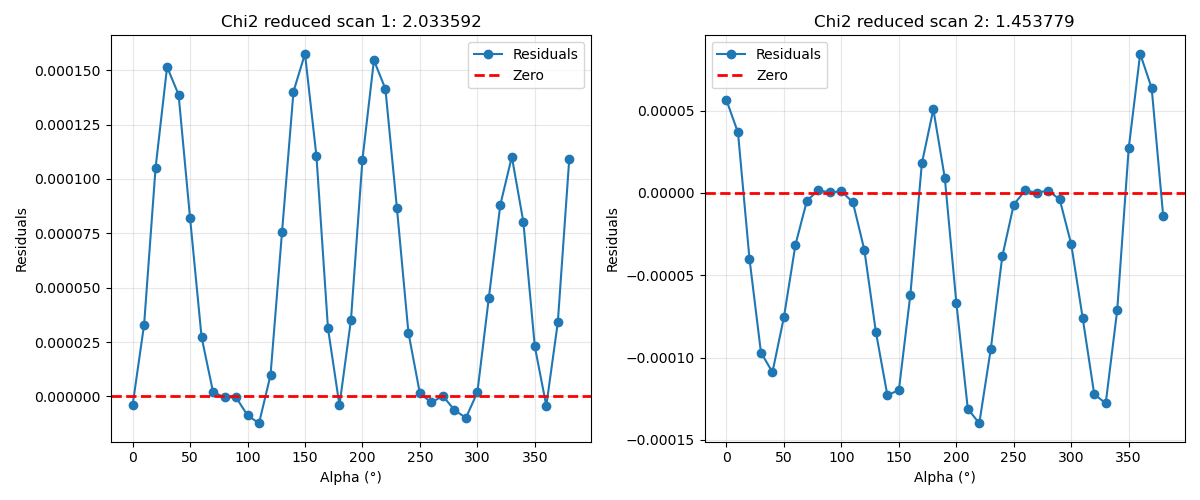

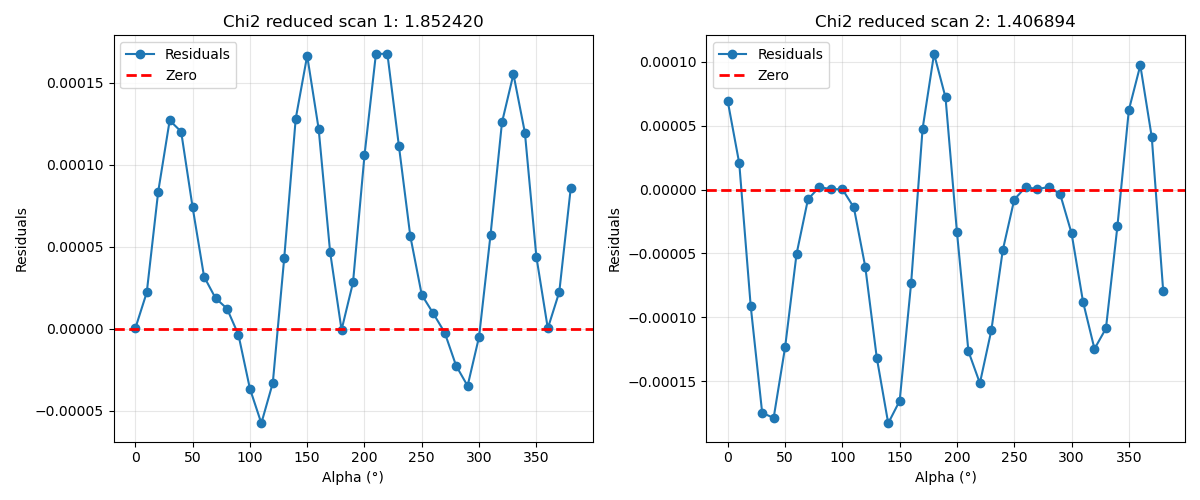

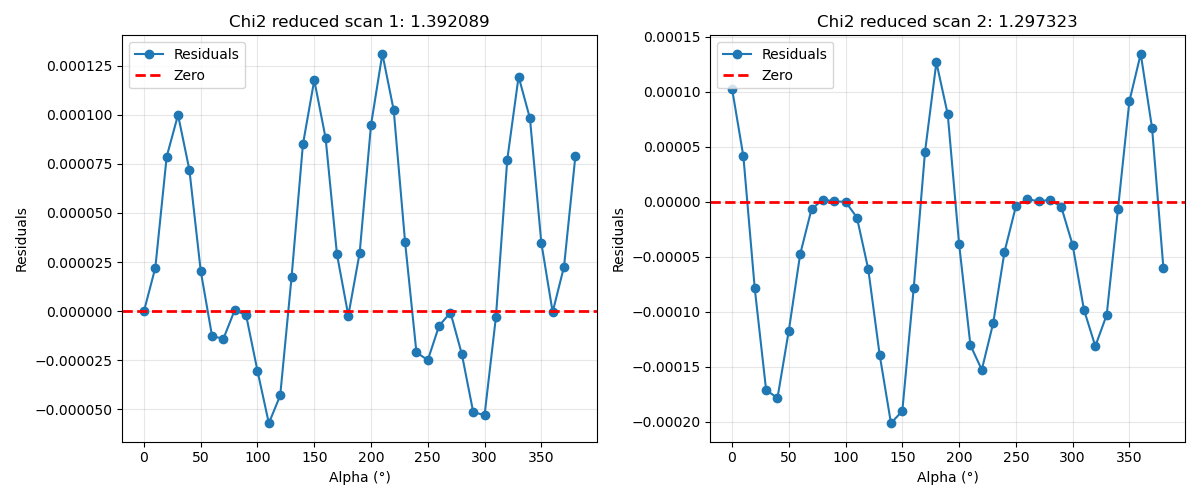

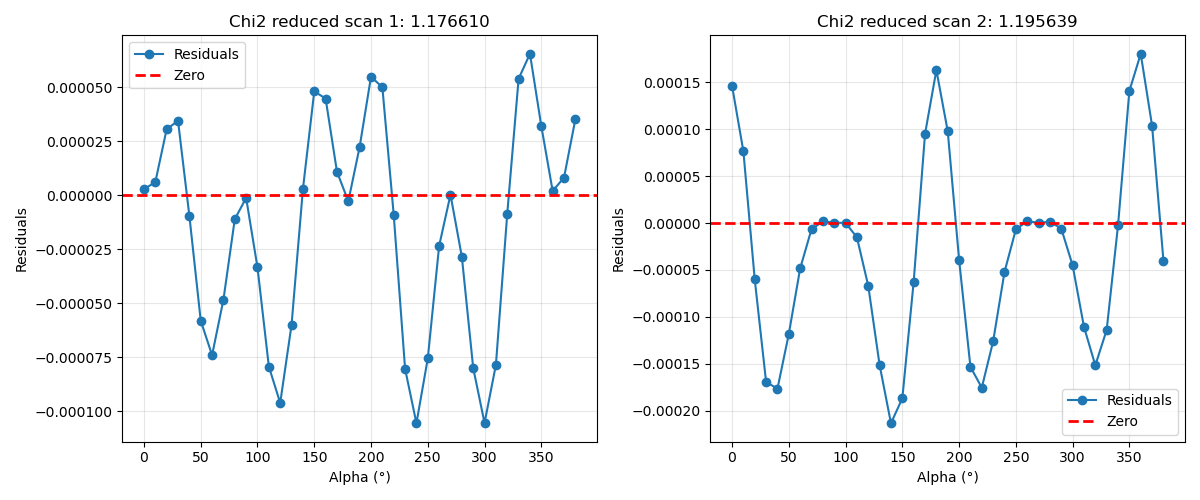

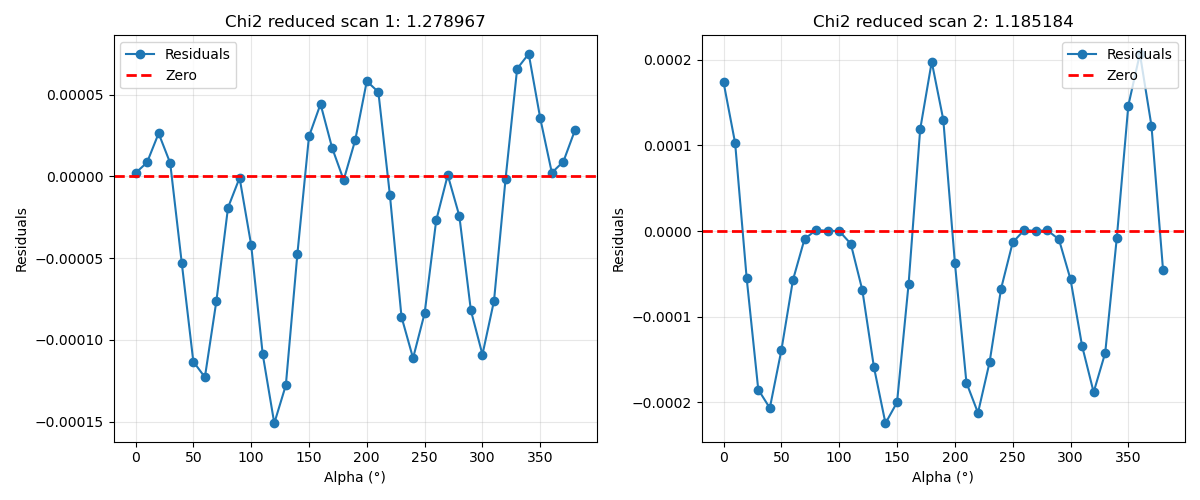

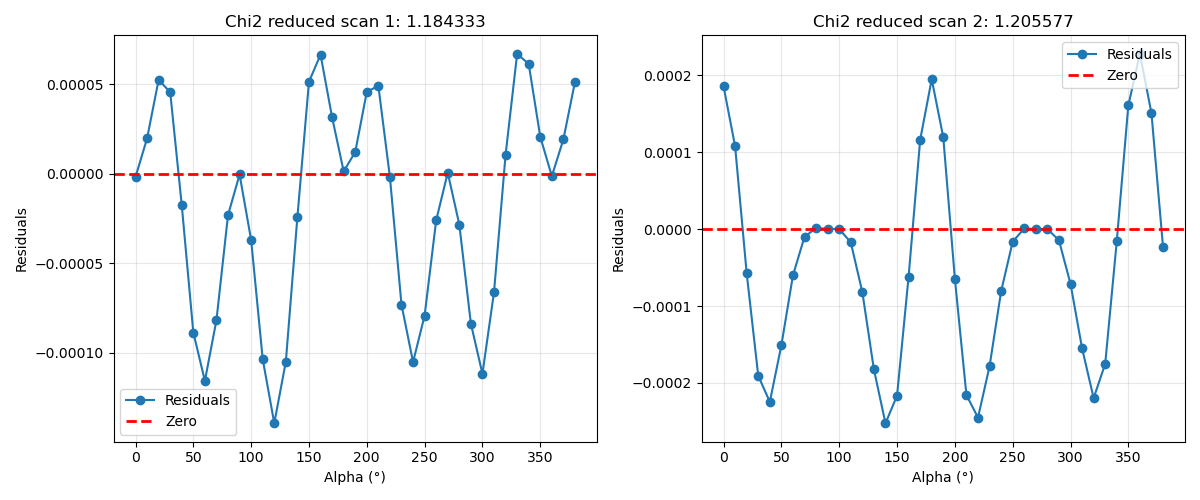

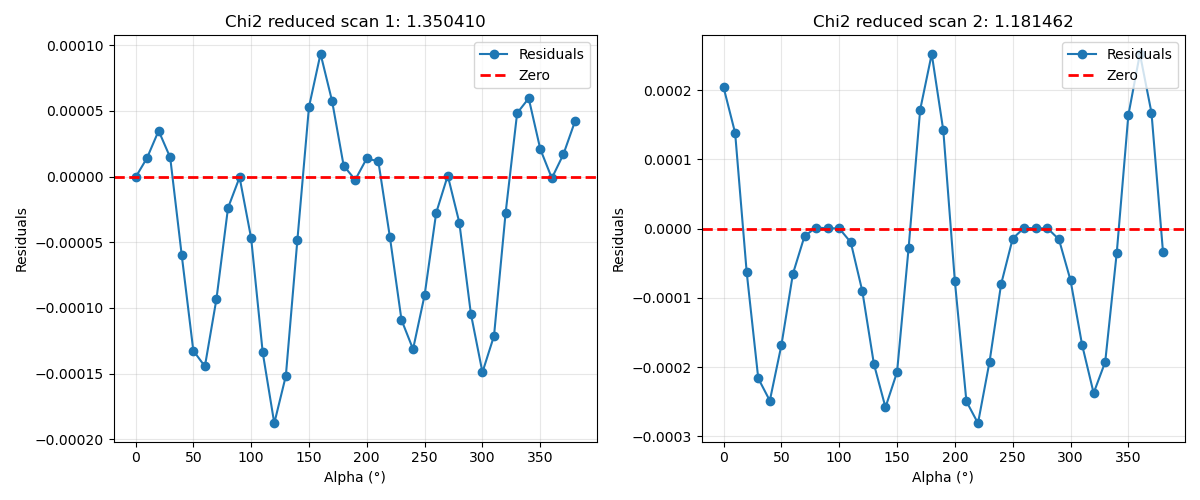

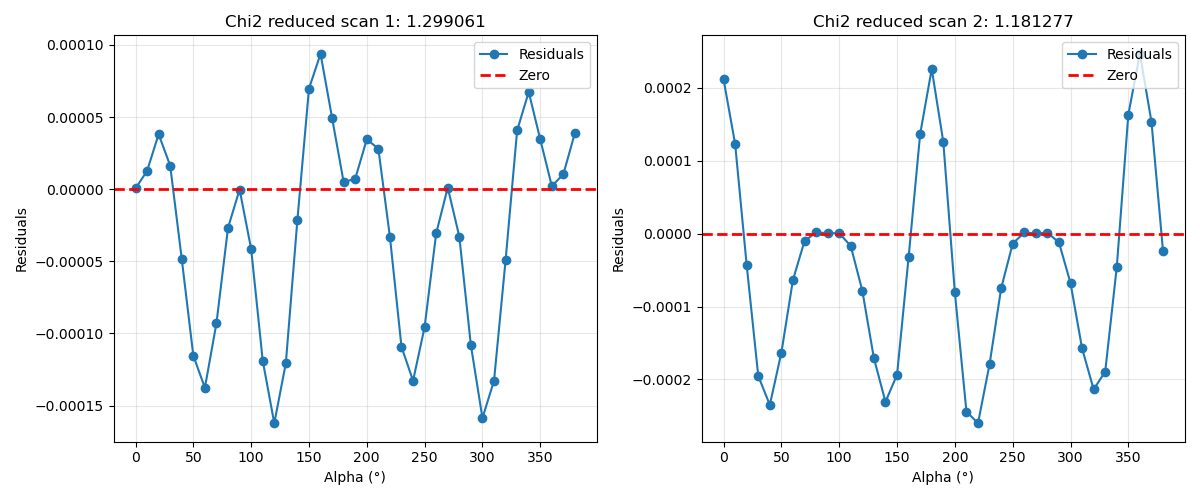

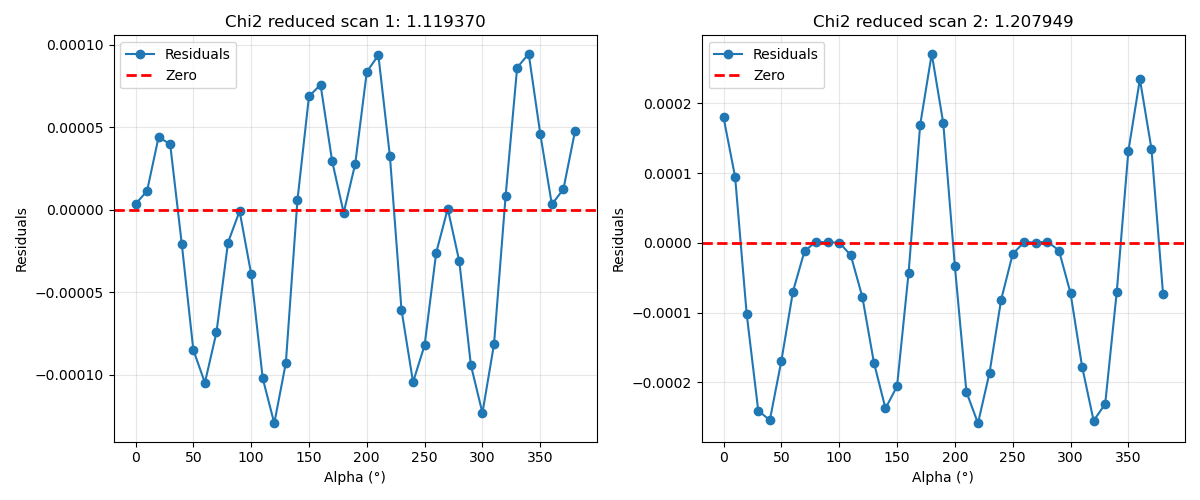

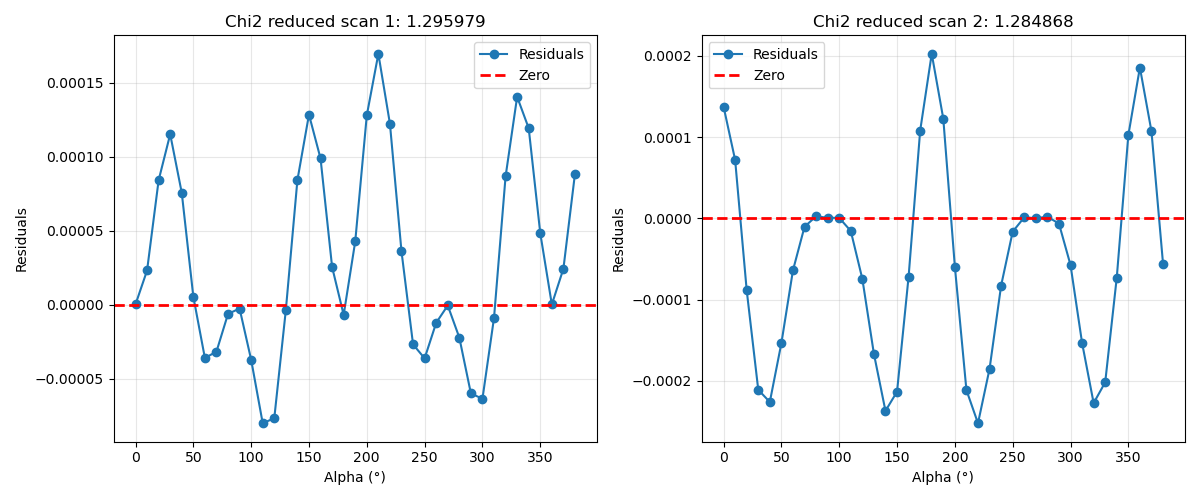

In [91]:
# Plot residuals
for f in range(fstart_ind, nfreqs, 10):  # Plot every 10th frequency to avoid overcrowding

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs = axs.flatten()

    # Plot residuals for scan 1
    axs[0].plot(alpha, all_residuals_scan1[f, :], 'o-', label='Residuals', markersize=6)
    axs[0].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero')
    axs[0].set_xlabel('Alpha (°)')
    axs[0].set_ylabel('Residuals')
    axs[0].set_title(f'Chi2 reduced scan 1: {all_chi2red_scan1[f]:.6f}')
    axs[0].grid(alpha=0.3)
    axs[0].legend()

    # Plot residuals for scan 2
    axs[1].plot(alpha, all_residuals_scan2[f, :], 'o-', label='Residuals', markersize=6)
    axs[1].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero')
    axs[1].set_xlabel('Alpha (°)')
    axs[1].set_ylabel('Residuals')
    axs[1].set_title(f'Chi2 reduced scan 2: {all_chi2red_scan2[f]:.6f}')
    axs[1].grid(alpha=0.3)
    axs[1].legend()

    fig.tight_layout()
    plt.show()
